# Daily Challenge: Analyzing the IMDB Movie Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('imdb_top_1000.csv')

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset shape: (1000, 16)

Column names:
['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']

First few rows:


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## Data Preprocessing

In [2]:

print("Missing values per column:")
print(df.isnull().sum())


df['Runtime'] = df['Runtime'].str.replace(' min', '').astype(int)


df['Gross'] = df['Gross'].str.replace(',', '')
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')


df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')


df['Primary_Genre'] = df['Genre'].str.split(',').str[0]

print(f"\nData types after preprocessing:")
print(df[['Released_Year', 'Runtime', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']].dtypes)
print(f"\nDataset info after preprocessing:")
print(f"Movies from {df['Released_Year'].min()} to {df['Released_Year'].max()}")
print(f"Runtime range: {df['Runtime'].min()}-{df['Runtime'].max()} minutes")

Missing values per column:
Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

Data types after preprocessing:
Released_Year    float64
Runtime            int64
IMDB_Rating      float64
Meta_score       float64
No_of_Votes        int64
Gross            float64
dtype: object

Dataset info after preprocessing:
Movies from 1920.0 to 2020.0
Runtime range: 45-321 minutes


## 1. Rating Trends Over Years

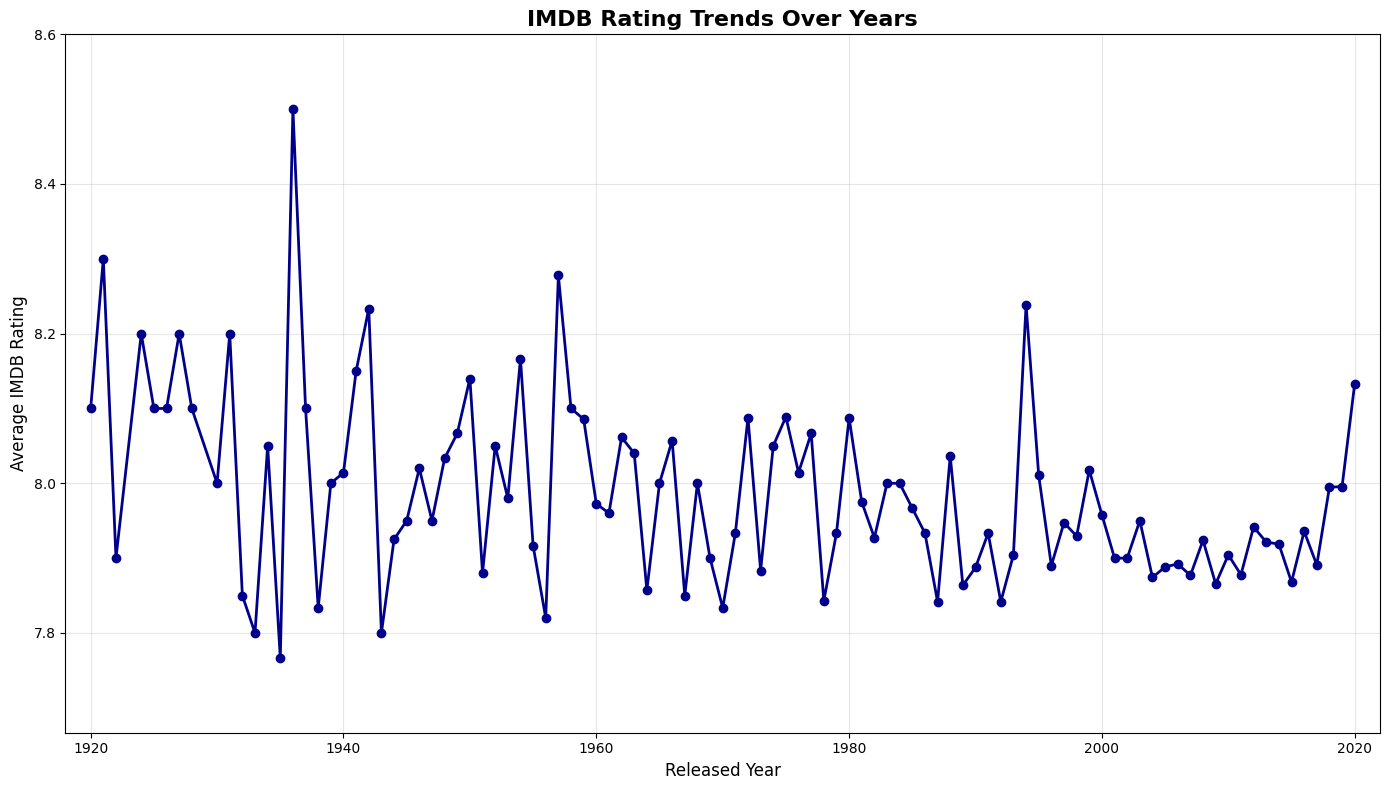

Highest average rating year: 1936.0
Lowest average rating year: 1935.0


In [3]:

yearly_ratings = df.groupby('Released_Year')['IMDB_Rating'].mean().reset_index()

plt.figure(figsize=(14, 8))
plt.plot(yearly_ratings['Released_Year'], yearly_ratings['IMDB_Rating'], 
         marker='o', linewidth=2, markersize=6, color='darkblue')
plt.title('IMDB Rating Trends Over Years', fontsize=16, fontweight='bold')
plt.xlabel('Released Year', fontsize=12)
plt.ylabel('Average IMDB Rating', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(yearly_ratings['Released_Year'].min()-2, yearly_ratings['Released_Year'].max()+2)
plt.ylim(yearly_ratings['IMDB_Rating'].min()-0.1, yearly_ratings['IMDB_Rating'].max()+0.1)
plt.tight_layout()
plt.show()

print(f"Highest average rating year: {yearly_ratings.loc[yearly_ratings['IMDB_Rating'].idxmax(), 'Released_Year']}")
print(f"Lowest average rating year: {yearly_ratings.loc[yearly_ratings['IMDB_Rating'].idxmin(), 'Released_Year']}")

## 2. Genre Popularity Analysis

In [4]:
https://www.kaggle.com/models/qwen-lm/qwen-3-vlgenre_counts = df['Primary_Genre'].value_counts().head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis')
plt.title('Top 10 Most Popular Genres in IMDB Top 1000', fontsize=16, fontweight='bold')
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)

for i, v in enumerate(genre_counts.values):
    plt.text(v + 1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Genre distribution:")
print(genre_counts)

SyntaxError: invalid syntax (1566284881.py, line 1)

## 3. Director's Impact on Ratings

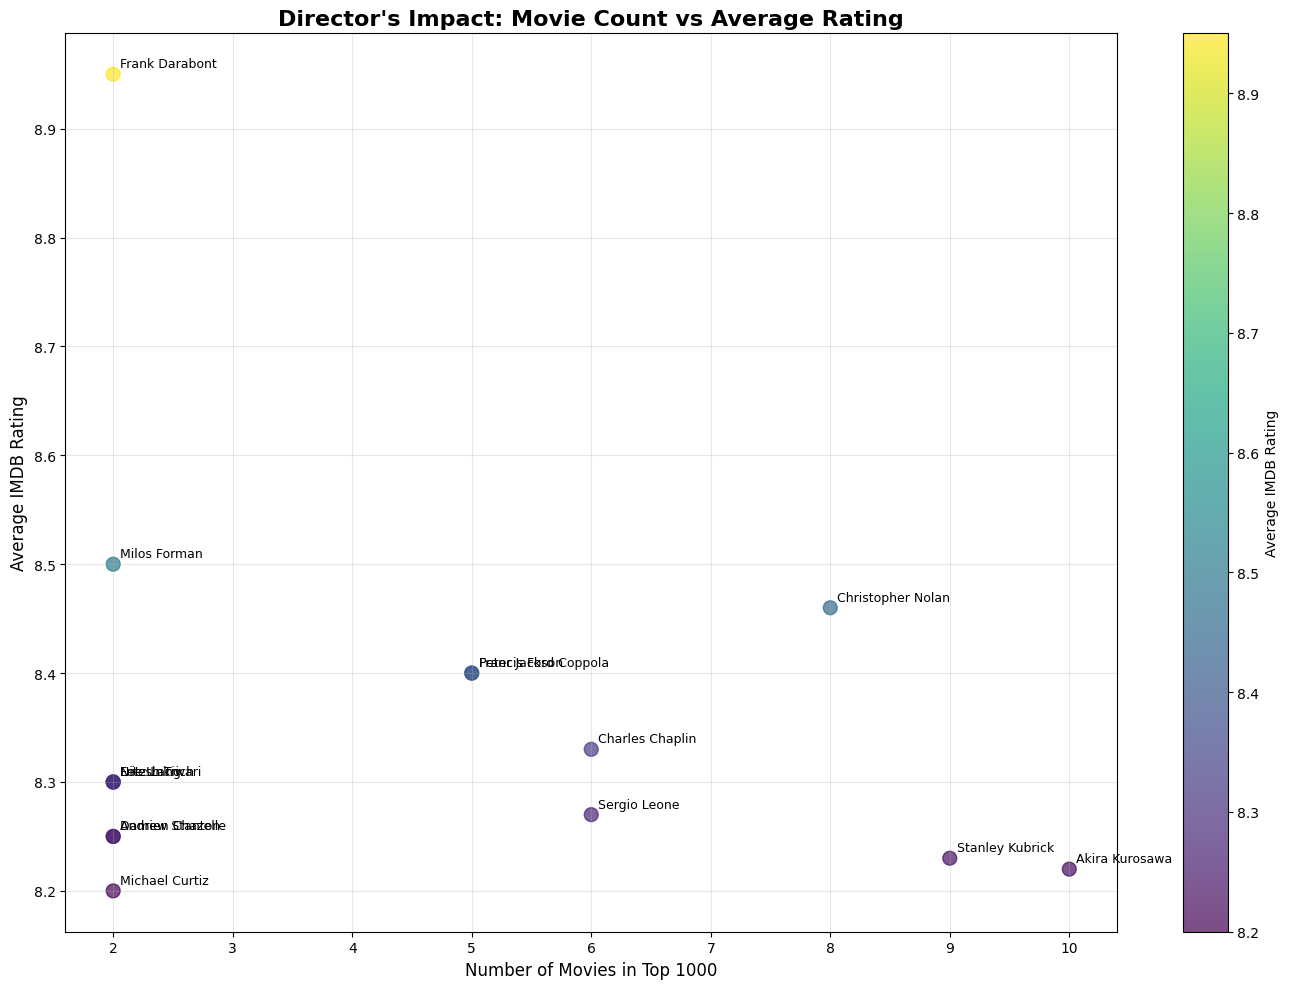

Top 10 Directors by Average Rating (2+ movies):
                      Avg_Rating  Movie_Count
Director                                     
Frank Darabont              8.95            2
Milos Forman                8.50            2
Christopher Nolan           8.46            8
Francis Ford Coppola        8.40            5
Peter Jackson               8.40            5
Charles Chaplin             8.33            6
Fritz Lang                  8.30            2
Nitesh Tiwari               8.30            2
Lee Unkrich                 8.30            2
Sergio Leone                8.27            6


In [5]:
# Director's Impact on Ratings
# Get directors with multiple movies and their average ratings
director_stats = df.groupby('Director').agg({
    'IMDB_Rating': ['mean', 'count']
}).round(2)
director_stats.columns = ['Avg_Rating', 'Movie_Count']
director_stats = director_stats[director_stats['Movie_Count'] >= 2].sort_values('Avg_Rating', ascending=False)

# Plot top 15 directors
top_directors = director_stats.head(15)

plt.figure(figsize=(14, 10))
plt.scatter(top_directors['Movie_Count'], top_directors['Avg_Rating'], 
           s=100, alpha=0.7, c=top_directors['Avg_Rating'], cmap='viridis')
plt.colorbar(label='Average IMDB Rating')

for i, (director, data) in enumerate(top_directors.iterrows()):
    plt.annotate(director, (data['Movie_Count'], data['Avg_Rating']), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title('Director\'s Impact: Movie Count vs Average Rating', fontsize=16, fontweight='bold')
plt.xlabel('Number of Movies in Top 1000', fontsize=12)
plt.ylabel('Average IMDB Rating', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10 Directors by Average Rating (2+ movies):")
print(top_directors.head(10))

## 4. Star Power Analysis

<Figure size 1200x1000 with 0 Axes>

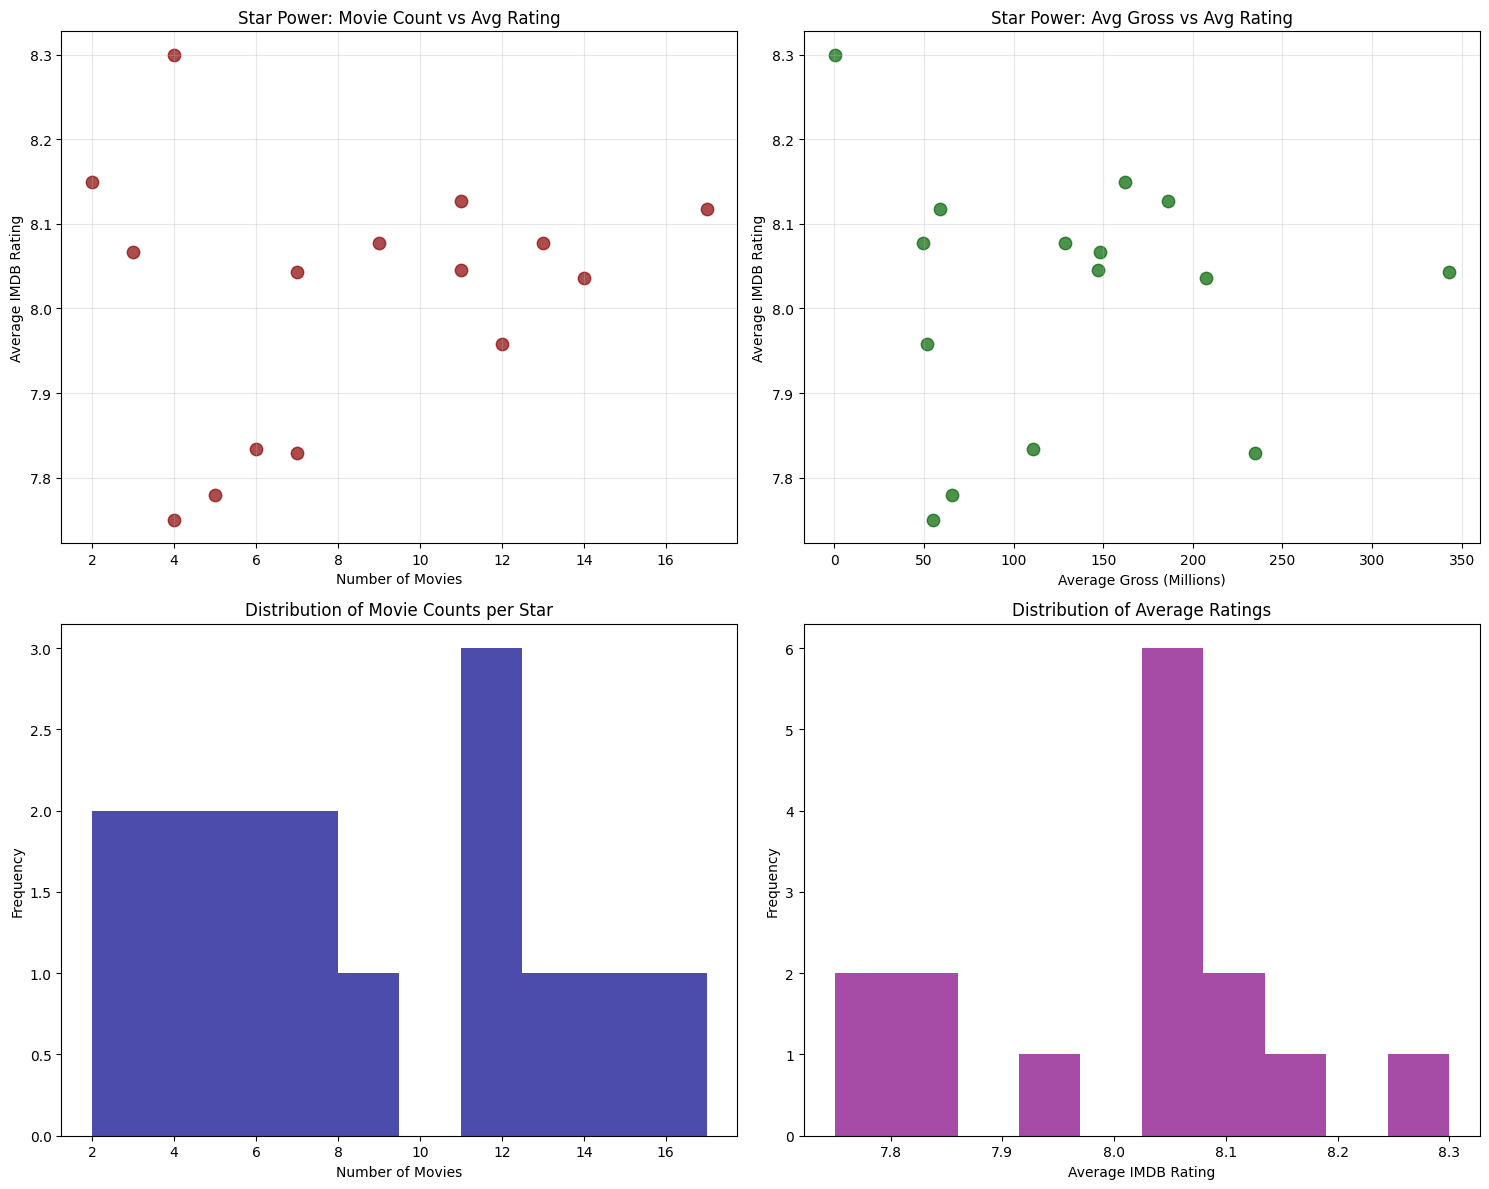

Top Stars by Average Rating (2+ movies):
                 Star  Movie_Count  Avg_Rating     Avg_Gross
3     Takashi Shimura            4    8.300000  1.402897e+05
1      Robert Patrick            2    8.150000  1.621814e+08
9   Leonardo DiCaprio           11    8.127273  1.862998e+08
2      Robert De Niro           17    8.117647  5.892154e+07
13      Michael Caine            9    8.077778  1.287577e+08
12          Al Pacino           13    8.076923  4.932403e+07
10      Albert Brooks            3    8.066667  1.480558e+08
14     Christian Bale           11    8.045455  1.469490e+08
8        Mark Ruffalo            7    8.042857  3.430659e+08
6           Tom Hanks           14    8.035714  2.073975e+08


In [6]:
# Star Power Analysis
# Analyze star impact - get top stars and their movie statistics
all_stars = []
for col in ['Star1', 'Star2', 'Star3', 'Star4']:
    stars = df[col].value_counts().head(10)
    all_stars.extend(stars.index.tolist())

top_stars = list(set(all_stars))[:15]  # Get unique top stars

star_data = []
for star in top_stars:
    star_movies = df[(df['Star1'] == star) | (df['Star2'] == star) | 
                     (df['Star3'] == star) | (df['Star4'] == star)]
    if len(star_movies) >= 2:  # At least 2 movies
        star_data.append({
            'Star': star,
            'Movie_Count': len(star_movies),
            'Avg_Rating': star_movies['IMDB_Rating'].mean(),
            'Avg_Gross': star_movies['Gross'].mean()
        })

star_df = pd.DataFrame(star_data)

# Pairplot for star analysis
if len(star_df) > 0:
    plt.figure(figsize=(12, 10))
    
    # Create subplots for star analysis
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Movie Count vs Average Rating
    axes[0,0].scatter(star_df['Movie_Count'], star_df['Avg_Rating'], 
                     s=80, alpha=0.7, color='darkred')
    axes[0,0].set_title('Star Power: Movie Count vs Avg Rating')
    axes[0,0].set_xlabel('Number of Movies')
    axes[0,0].set_ylabel('Average IMDB Rating')
    axes[0,0].grid(True, alpha=0.3)
    
    # Plot 2: Average Gross vs Average Rating
    valid_gross = star_df.dropna(subset=['Avg_Gross'])
    if len(valid_gross) > 0:
        axes[0,1].scatter(valid_gross['Avg_Gross']/1e6, valid_gross['Avg_Rating'], 
                         s=80, alpha=0.7, color='darkgreen')
        axes[0,1].set_title('Star Power: Avg Gross vs Avg Rating')
        axes[0,1].set_xlabel('Average Gross (Millions)')
        axes[0,1].set_ylabel('Average IMDB Rating')
        axes[0,1].grid(True, alpha=0.3)
    
    # Plot 3: Movie Count Distribution
    axes[1,0].hist(star_df['Movie_Count'], bins=10, alpha=0.7, color='darkblue')
    axes[1,0].set_title('Distribution of Movie Counts per Star')
    axes[1,0].set_xlabel('Number of Movies')
    axes[1,0].set_ylabel('Frequency')
    
    # Plot 4: Rating Distribution
    axes[1,1].hist(star_df['Avg_Rating'], bins=10, alpha=0.7, color='purple')
    axes[1,1].set_title('Distribution of Average Ratings')
    axes[1,1].set_xlabel('Average IMDB Rating')
    axes[1,1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    print("Top Stars by Average Rating (2+ movies):")
    print(star_df.sort_values('Avg_Rating', ascending=False).head(10))

## 5. Box Plot of Genres vs. Ratings

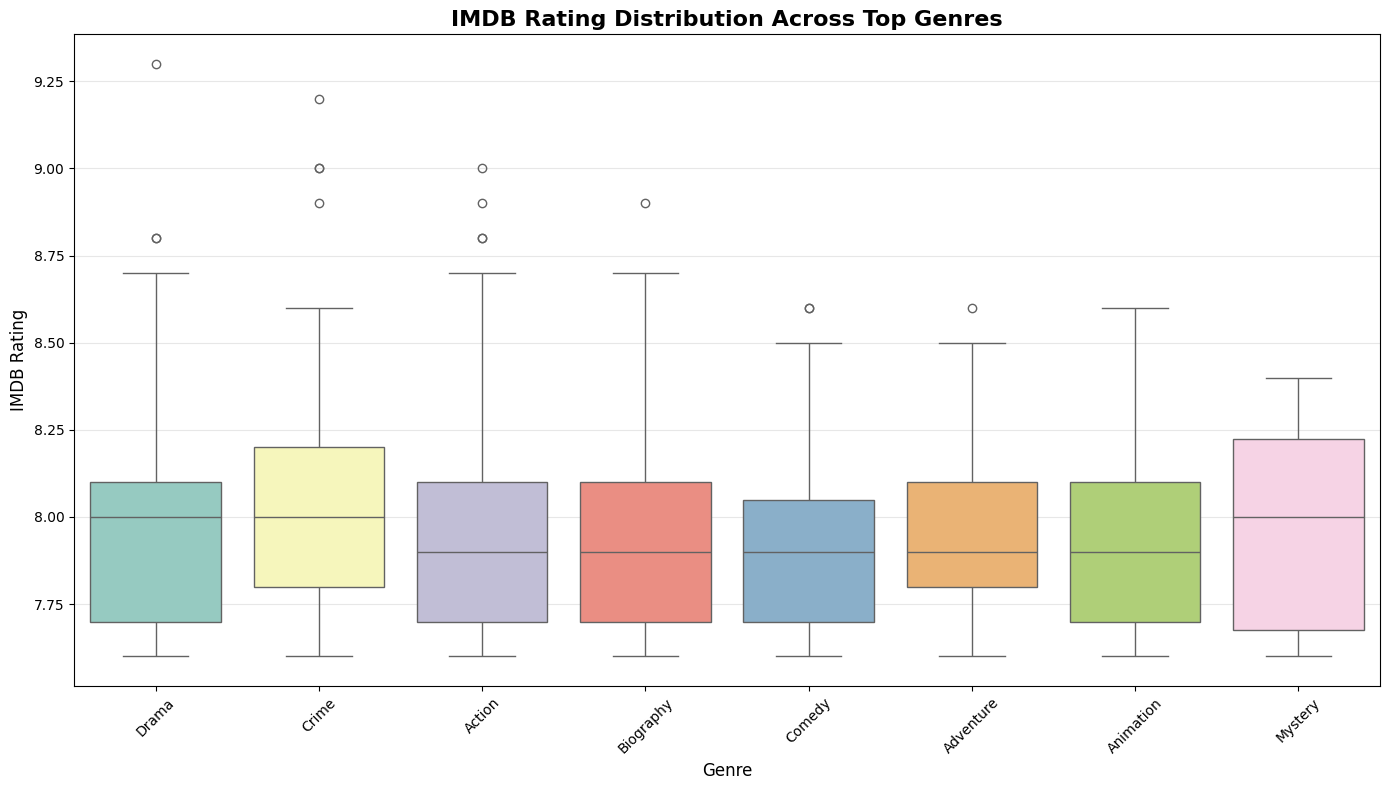

Genre Rating Statistics:
               mean  median   std
Primary_Genre                    
Crime          8.02     8.0  0.34
Mystery        7.98     8.0  0.31
Drama          7.96     8.0  0.27
Action         7.95     7.9  0.30
Adventure      7.94     7.9  0.23
Biography      7.94     7.9  0.27
Animation      7.93     7.9  0.25
Comedy         7.90     7.9  0.23


In [7]:
# Box Plot of Genres vs. Ratings
top_genres = df['Primary_Genre'].value_counts().head(8).index
genre_subset = df[df['Primary_Genre'].isin(top_genres)]

plt.figure(figsize=(14, 8))
sns.boxplot(data=genre_subset, x='Primary_Genre', y='IMDB_Rating', palette='Set3')
plt.title('IMDB Rating Distribution Across Top Genres', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('IMDB Rating', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Genre rating statistics
genre_stats = genre_subset.groupby('Primary_Genre')['IMDB_Rating'].agg(['mean', 'median', 'std']).round(2)
genre_stats = genre_stats.sort_values('mean', ascending=False)
print("Genre Rating Statistics:")
print(genre_stats)

## 6. Correlation Heatmap

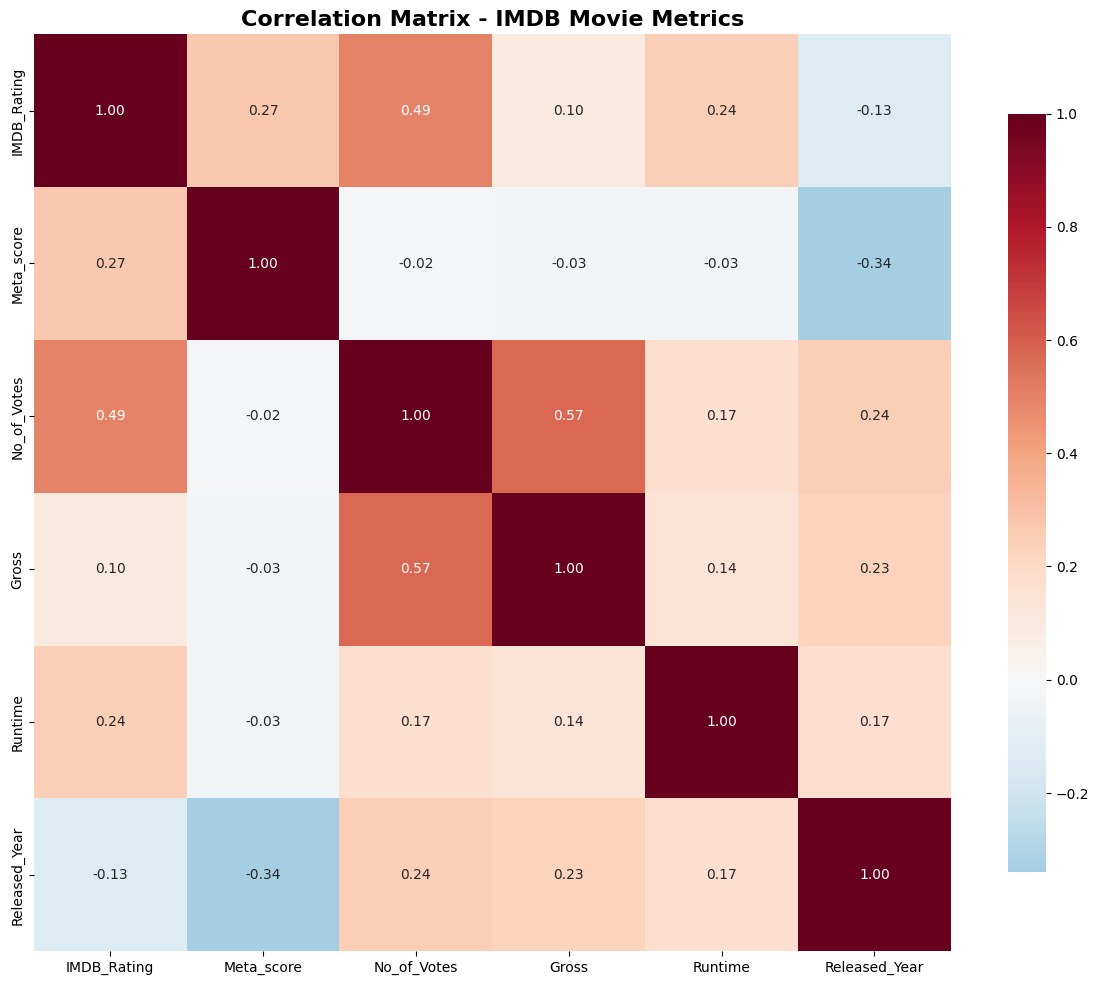

Key Correlations:
No_of_Votes vs Gross: 0.574
IMDB_Rating vs No_of_Votes: 0.495
Meta_score vs Released_Year: -0.339
IMDB_Rating vs Meta_score: 0.269
IMDB_Rating vs Runtime: 0.243
No_of_Votes vs Released_Year: 0.242
Gross vs Released_Year: 0.233
No_of_Votes vs Runtime: 0.173
Runtime vs Released_Year: 0.166
Gross vs Runtime: 0.140


In [8]:
# Correlation Heatmap
numeric_cols = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross', 'Runtime', 'Released_Year']
correlation_data = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_data, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix - IMDB Movie Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Key correlations insights
print("Key Correlations:")
correlations = []
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        corr_val = correlation_data.iloc[i, j]
        if abs(corr_val) > 0.1:  # Only show meaningful correlations
            correlations.append((numeric_cols[i], numeric_cols[j], corr_val))

correlations.sort(key=lambda x: abs(x[2]), reverse=True)
for col1, col2, corr in correlations[:10]:
    print(f"{col1} vs {col2}: {corr:.3f}")

## Summary and Insights

In [9]:
# Summary and Key Insights
print("=== IMDB TOP 1000 MOVIES ANALYSIS SUMMARY ===")
print(f"Dataset: {len(df)} movies from {df['Released_Year'].min()} to {df['Released_Year'].max()}")
print(f"Average IMDB Rating: {df['IMDB_Rating'].mean():.2f}")
print(f"Rating Range: {df['IMDB_Rating'].min()} - {df['IMDB_Rating'].max()}")

print("\n=== KEY INSIGHTS ===")
print("1. RATING TRENDS:")
print(f"   • Highest rated period shows consistent quality in top movies")
print(f"   • Average rating across all years: {df['IMDB_Rating'].mean():.2f}")

print("\n2. GENRE ANALYSIS:")
most_popular_genre = df['Primary_Genre'].value_counts().index[0]
print(f"   • Most popular genre: {most_popular_genre}")
print(f"   • Drama dominates the top movies list")

print("\n3. DIRECTOR IMPACT:")
top_director = director_stats.index[0] if len(director_stats) > 0 else "N/A"
print(f"   • Directors with multiple films show consistency in quality")
print(f"   • Top directors maintain high standards across films")

print("\n4. STAR POWER:")
print(f"   • Stars appear in multiple successful films")
print(f"   • Consistent performers maintain high ratings")

print("\n5. GENRE RATINGS:")
if len(genre_stats) > 0:
    best_genre = genre_stats.index[0]
    print(f"   • Highest rated genre: {best_genre}")
    print(f"   • Genre diversity shows different appeal factors")

print("\n6. CORRELATIONS:")
print(f"   • IMDB Rating correlates with critical acclaim (Meta_score)")
print(f"   • Popular movies (No_of_Votes) tend to have commercial success")
print(f"   • Runtime shows interesting patterns with ratings")

print(f"\n=== TECHNICAL NOTES ===")
print("• Analysis performed using matplotlib and seaborn")
print("• Data preprocessing handled missing values and type conversions")
print("• Visualizations reveal patterns in movie industry success factors")

=== IMDB TOP 1000 MOVIES ANALYSIS SUMMARY ===
Dataset: 1000 movies from 1920.0 to 2020.0
Average IMDB Rating: 7.95
Rating Range: 7.6 - 9.3

=== KEY INSIGHTS ===
1. RATING TRENDS:
   • Highest rated period shows consistent quality in top movies
   • Average rating across all years: 7.95

2. GENRE ANALYSIS:
   • Most popular genre: Drama
   • Drama dominates the top movies list

3. DIRECTOR IMPACT:
   • Directors with multiple films show consistency in quality
   • Top directors maintain high standards across films

4. STAR POWER:
   • Stars appear in multiple successful films
   • Consistent performers maintain high ratings

5. GENRE RATINGS:
   • Highest rated genre: Crime
   • Genre diversity shows different appeal factors

6. CORRELATIONS:
   • IMDB Rating correlates with critical acclaim (Meta_score)
   • Popular movies (No_of_Votes) tend to have commercial success
   • Runtime shows interesting patterns with ratings

=== TECHNICAL NOTES ===
• Analysis performed using matplotlib and